1: Import Library (Menyiapkan Alat

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

2: Fungsi GLCM & Jarak (Otak Program)

In [2]:
# 1. Fungsi Ekstraksi GLCM
def ekstrak_fitur_glcm(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Preprocessing: Ukuran seragam & ubah ke Hitam Putih (Grayscale)
    img_resized = cv2.resize(img, (256, 256))
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # Hitung matriks GLCM sudut bertetangga
    glcm = graycomatrix(img_gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)

    # Ambil 4 fitur statistik utama
    contrast = np.mean(graycoprops(glcm, 'contrast'))
    correlation = np.mean(graycoprops(glcm, 'correlation'))
    energy = np.mean(graycoprops(glcm, 'energy'))
    homogeneity = np.mean(graycoprops(glcm, 'homogeneity'))

    return np.array([contrast, correlation, energy, homogeneity])

# 2. Fungsi Hitung Jarak Euclidean
def hitung_jarak_euclidean(vektor1, volver2):
    return np.sqrt(np.sum((vektor1 - volver2) ** 2))

3: Training / Membaca Gambar Acuan

In [3]:
# Menentukan file acuan yang ada di folder Colab
path_segar = "segar.jpeg"
path_busuk = "busuk.jpeg"

# Ekstrak nilai fitur masing-masing gambar
fitur_segar = ekstrak_fitur_glcm(path_segar)
fitur_busuk = ekstrak_fitur_glcm(path_busuk)

print("=== NILAI EKSTRAKSI FITUR GLCM ===")
print("Fitur Daging Segar :", fitur_segar)
print("Fitur Daging Busuk :", fitur_busuk)
print("==================================")

=== NILAI EKSTRAKSI FITUR GLCM ===
Fitur Daging Segar : [2.73572372e+02 8.68597498e-01 2.06421018e-02 1.23996277e-01]
Fitur Daging Busuk : [1.23155590e+02 9.79017440e-01 1.45161593e-02 1.72360255e-01]


4: Fungsi Pengujian & Hasil Klasifikasi

In [4]:
# Fungsi klasifikasi gambar baru
def klasifikasi_daging(image_test_path):
    fitur_uji = ekstrak_fitur_glcm(image_test_path)
    if fitur_uji is None:
        print(f"File '{image_test_path}' tidak ditemukan!")
        return

    jarak_ke_segar = hitung_jarak_euclidean(fitur_uji, fitur_segar)
    jarak_ke_busuk = hitung_jarak_euclidean(fitur_uji, fitur_busuk)

    print(f"--- Perhitungan Jarak untuk: {image_test_path} ---")
    print(f"Jarak ke Segar : {jarak_ke_segar:.4f}")
    print(f"Jarak ke Busuk : {jarak_ke_busuk:.4f}")

    if jarak_ke_segar < jarak_ke_busuk:
        hasil = "DAGING SEGAR"
    else:
        hasil = "DAGING BUSUK"

    print(f"\nHASIL KLASIFIKASI: [{hasil}]")

# ==========================================
# TEST JALANKAN PROGRAM DI SINI
# ==========================================
# Coba tes panggil gambar segar.jpeg, harusnya keluar hasil DAGING SEGAR
klasifikasi_daging("segar.jpeg")

--- Perhitungan Jarak untuk: segar.jpeg ---
Jarak ke Segar : 0.0000
Jarak ke Busuk : 150.4168

HASIL KLASIFIKASI: [DAGING SEGAR]


(Sel 5)

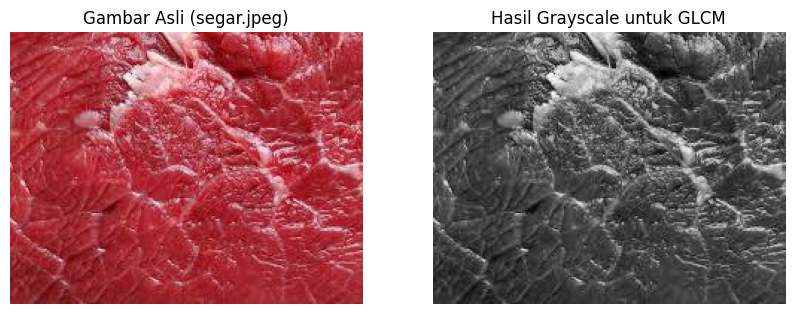

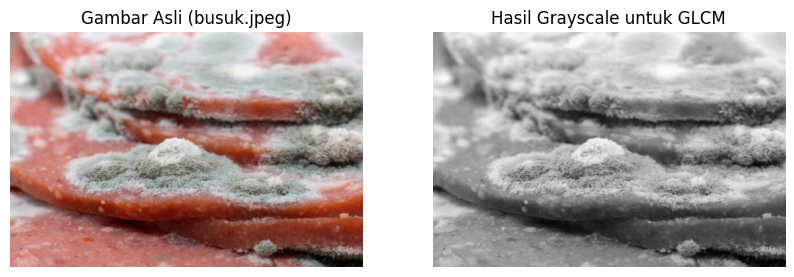

In [5]:
# SEL 5: BONUS UNTUK MENAMPILKAN GAMBAR (BIAR DOSEN/ASPRAK MAKIN PUAS)
def tampilkan_proses_citra(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Gambar tidak ditemukan.")
        return

    # Proses konversi warna untuk ditampilkan di plot
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Mulai menggambar panel visualisasi
    plt.figure(figsize=(10, 5))

    # 1. Tampilkan Gambar Asli Berwarna
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Gambar Asli ({image_path})")
    plt.axis('off')

    # 2. Tampilkan Gambar Hasil Grayscale (Hitam Putih)
    plt.subplot(1, 2, 2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Hasil Grayscale untuk GLCM")
    plt.axis('off')

    plt.show()

# ==========================================
# JALANKAN UNTUK MEMUNCULKAN GAMBAR
# ==========================================
# Coba jalankan untuk melihat proses gambar segar
tampilkan_proses_citra("segar.jpeg")

# Coba jalankan untuk melihat proses gambar busuk
tampilkan_proses_citra("busuk.jpeg")